In [2]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import re

In [3]:
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\varad\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
df = pd.read_csv("data/tweets.csv", low_memory=False)

df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1406400408545804288,1406400396264943616,2021-06-20 05:26:01 IST,2021-06-20,05:26:01,530,1113747629282930688,ballouxfrancois,Prof Francois Balloux,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,1406390341176016897,1406390341176016897,2021-06-20 04:46:01 IST,2021-06-20,04:46:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1406386311481774083,1406386311481774083,2021-06-20 04:30:00 IST,2021-06-20,04:30:00,530,19402238,sciencenews,Science News,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1406383545153638402,1406383545153638402,2021-06-20 04:19:01 IST,2021-06-20,04:19:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1406358632648818689,1406358632648818689,2021-06-20 02:40:01 IST,2021-06-20,02:40:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [5]:
tweets = df["tweet"]

tweets.head()

0    What can be done?  - Never blindly trust an ab...
1    "We need a paradigm shift from model-centric t...
2    Using high-resolution satellite data and compu...
3    .@Stephenson_Data shares four steps that will ...
4    "Curricula is inherently brittle in a world wh...
Name: tweet, dtype: object

In [7]:
def clean_tweet(tweet):
    
    tweet = tweet.lower()
    
    tweet = re.sub(r'http\S+', '', tweet)  # remove urls
    tweet = re.sub(r'@\w+', '', tweet)     # remove mentions
    tweet = re.sub(r'#', '', tweet)        # remove hashtag symbol
    tweet = re.sub(r'[^\w\s]', '', tweet)  # remove punctuation
    
    tweet = tweet.strip()
    
    return tweet

In [8]:
cleaned_tweets = tweets.apply(clean_tweet)

cleaned_tweets.head()

0    what can be done   never blindly trust an abst...
1    we need a paradigm shift from modelcentric to ...
2    using highresolution satellite data and comput...
3    shares four steps that will help new data scie...
4    curricula is inherently brittle in a world whe...
Name: tweet, dtype: object

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [10]:
def get_sentiment(tweet):
    
    score = sia.polarity_scores(tweet)
    
    if score['compound'] >= 0.05:
        return "Positive"
    
    elif score['compound'] <= -0.05:
        return "Negative"
    
    else:
        return "Neutral"

In [11]:
df["sentiment"] = cleaned_tweets.apply(get_sentiment)

df[["tweet","sentiment"]].head()

,tweet,sentiment
0,What can be done? - Never blindly trust an ab...,Negative
1,"""We need a paradigm shift from model-centric t...",Neutral
2,Using high-resolution satellite data and compu...,Neutral
3,.@Stephenson_Data shares four steps that will ...,Positive
4,"""Curricula is inherently brittle in a world wh...",Positive


In [12]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
Positive    120827
Neutral      96659
Negative     23900
Name: count, dtype: int64

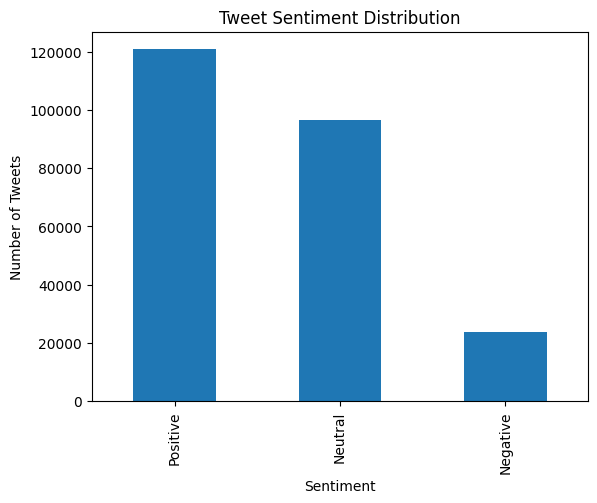

In [13]:
sentiment_counts.plot(kind='bar')

plt.title("Tweet Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

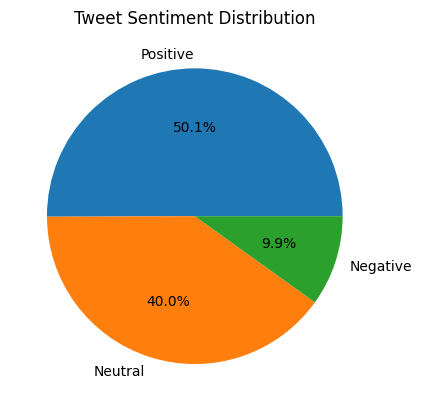

In [17]:
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Tweet Sentiment Distribution")
plt.ylabel("")
plt.show()

In [14]:
print("Positive Tweets:\n")
print(df[df["sentiment"]=="Positive"]["tweet"].head())

print("\nNegative Tweets:\n")
print(df[df["sentiment"]=="Negative"]["tweet"].head())

Positive Tweets:

3     .@Stephenson_Data shares four steps that will ...
4     "Curricula is inherently brittle in a world wh...
6     @LinkLabsInc @IoTchannel Wow! Wonderful!! Cong...
9     Demystifying #AI with 10 top applications:  ht...
10    Trends in #AI for next 5 years, including reve...
Name: tweet, dtype: object

Negative Tweets:

0     What can be done?  - Never blindly trust an ab...
5     Many common colour maps distort data through u...
36    Disruption defines our world, and the latest h...
37    The Science Table estimates for Delta spread c...
44    "I think problem formulation is even more impo...
Name: tweet, dtype: object


In [20]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


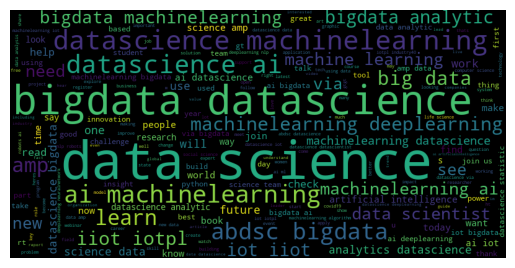

In [21]:
from wordcloud import WordCloud

text = " ".join(cleaned_tweets)

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [22]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [24]:
X = cleaned_tweets
y = df["sentiment"]

In [25]:
vectorizer = TfidfVectorizer(max_features=5000)

X_vectorized = vectorizer.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [27]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.86      0.64      0.73      4798
     Neutral       0.91      0.98      0.94     19460
    Positive       0.95      0.94      0.95     24020

    accuracy                           0.93     48278
   macro avg       0.91      0.85      0.87     48278
weighted avg       0.93      0.93      0.92     48278



In [31]:
sample_tweet = ["I may working with machine learning models"]

sample_vec = vectorizer.transform(sample_tweet)

prediction = model.predict(sample_vec)

print("Tweet:", sample_tweet[0])
print("Predicted Sentiment:", prediction[0])

Tweet: I may working with machine learning models
Predicted Sentiment: Neutral
